Pilot Analysis 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Get the script's directory and search upward for Data and Results folders
current = Path(os.getcwd())

# Walk up until we find a folder that contains both Data and Results
while current != current.parent:
    if (current / 'Data').exists() and (current / 'Results').exists():
        repo_root = current
        break
    current = current.parent
else:
    raise FileNotFoundError("Could not find repo root (folder containing both Data and Results)")

# Define file paths relative to repo root
gt_path = repo_root / 'data/improved/full_ground_truth_improved.csv'
llm_path = repo_root / 'results/full/full_llm_output_improved.csv'

# Load data
gt = pd.read_csv(gt_path)
llm = pd.read_csv(llm_path)

gt['issue_key'] = (
    gt['BUG-ID'].astype(str)
    .str.replace(' Raw','', regex=False)
    .str.replace(' Improved','', regex=False)
)

df = gt.merge(llm, on='issue_key', how='inner')

print("Ground Truth:", len(gt))
print("LLM Output:", len(llm))
print("Merged:", len(df))

print("\nRepo root found at:", repo_root)

df.head()

Ground Truth: 139
LLM Output: 139
Merged: 139

Repo root found at: c:\Users\lamso\Documents\My portfolio website\SWT301_SE1925_G6


,BUG-ID,S2R Label,S2R Irrep Category,Reason,OB Category,OB Label,Reason_2,EB Category,EB Label,Reason_3,...,prompt_version,seed,system_fingerprint,input_tokens,cached_input_tokens,output_tokens,total_tokens,cost_usd,timestamp,raw_response
0,MC-298921 Improved,Executable,NaN,NaN,Present,Sufficient,NaN,Present,Inaccurate,CTRL + G and G are different commands can resu...,...,Prompts_Improved_Final_V19_DevelopmentTuned_Ru...,210,fp_3be5422b9d,5431,5376,209,5640,0.000537,2026-07-11T19:50:48,"{\r\n ""issue_key"": ""MC-298921"",\r\n ""steps_t..."
1,MC-299218 Improved,Non-Executable,Missing Information,No information for jukebox to work,Present,Sufficient,NaN,Present,Accurate,NaN,...,Prompts_Improved_Final_V19_DevelopmentTuned_Ru...,210,fp_3be5422b9d,5299,0,209,5508,0.000920,2026-07-11T19:59:07,"{\r\n ""issue_key"": ""MC-299218"",\r\n ""steps_t..."
2,MC-299342 Improved,Executable,NaN,Good Improvement to reproduce the bug,Present,Sufficient,NaN,Present,Accurate,NaN,...,Prompts_Improved_Final_V19_DevelopmentTuned_Ru...,210,fp_3be5422b9d,5550,0,221,5771,0.000965,2026-07-11T19:50:54,"{\r\n ""issue_key"": ""MC-299342"",\r\n ""steps_t..."
3,MC-299897 Improved,Executable,NaN,NaN,Present,Sufficient,NaN,Present,Accurate,NaN,...,Prompts_Improved_Final_V19_DevelopmentTuned_Ru...,210,fp_3be5422b9d,6351,0,210,6561,0.001079,2026-07-11T19:50:59,"{\r\n ""issue_key"": ""MC-299897"",\r\n ""steps_t..."
4,MC-299632 Improved,Non-Executable,Wrong Information,There is no command in 1.21.7 as'/give @p mine...,Present,Insufficient,"with no information provided, LLM tried to gue...",Present,Accurate,LLM explained the items user stated in the sum...,...,Prompts_Improved_Final_V19_DevelopmentTuned_Ru...,210,fp_3be5422b9d,5830,0,264,6094,0.001033,2026-07-11T19:51:07,"{\r\n ""issue_key"": ""MC-299632"",\r\n ""steps_t..."


In [16]:

LABEL_MAP = {
    'S2R Label':'s2r_label',
    'S2R Irrep Category':'s2r_failure_type',
    'OB Category':'observed_behavior_presence',
    'OB Label':'observed_behavior_quality',
    'EB Category':'expected_behavior_presence',
    'EB Label':'expected_behavior_quality'
}

results=[]

for gt_col,llm_col in LABEL_MAP.items():
    y_true=df[gt_col].fillna('MISSING').astype(str)
    y_pred=df[llm_col].fillna('MISSING').astype(str)

    results.append({
        'Dimension':gt_col,
        'Accuracy':accuracy_score(y_true,y_pred),
        'Precision(Macro)':precision_score(y_true,y_pred,average='macro',zero_division=0),
        'Recall(Macro)':recall_score(y_true,y_pred,average='macro',zero_division=0),
        'F1(Macro)':f1_score(y_true,y_pred,average='macro',zero_division=0)
    })

metrics_df=pd.DataFrame(results)
metrics_df


,Dimension,Accuracy,Precision(Macro),Recall(Macro),F1(Macro)
0,S2R Label,0.863309,0.901062,0.794681,0.823522
1,S2R Irrep Category,0.115108,0.239572,0.173099,0.198095
2,OB Category,1.000000,1.000000,1.000000,1.000000
3,OB Label,0.812950,0.206204,0.250000,0.226000
4,EB Category,0.985612,0.871296,0.871296,0.871296
5,EB Label,0.798561,0.207090,0.245575,0.224696


In [17]:

# Average metrics across all annotation dimensions
metrics_df[['Accuracy','Precision(Macro)','Recall(Macro)','F1(Macro)']].mean().to_frame('Mean Score')


,Mean Score
Accuracy,0.762590
Precision(Macro),0.570871
Recall(Macro),0.555775
F1(Macro),0.557268


In [18]:

# Quality scoring logic adapted from kappa_pilot.py

def score_row(s2r, irr, ob, obl, eb, ebl):
    s2r=str(s2r).strip().lower()
    irr=str(irr).strip().lower()
    ob=str(ob).strip().lower()
    obl=str(obl).strip().lower()
    eb=str(eb).strip().lower()
    ebl=str(ebl).strip().lower()

    if s2r == 'executable':
        if ob == 'present' and obl == 'sufficient' and eb == 'present' and ebl == 'accurate':
            return 5
        return 4

    if irr == 'wrong information':
        return 1

    if ob == 'present' and eb == 'present':
        return 3

    if ob == 'present' or eb == 'present':
        return 2

    return 1

df['gt_score'] = df.apply(
    lambda r: score_row(
        r['S2R Label'],
        r['S2R Irrep Category'],
        r['OB Category'],
        r['OB Label'],
        r['EB Category'],
        r['EB Label']
    ), axis=1
)

df['llm_score'] = df.apply(
    lambda r: score_row(
        r['s2r_label'],
        r['s2r_failure_type'],
        r['observed_behavior_presence'],
        r['observed_behavior_quality'],
        r['expected_behavior_presence'],
        r['expected_behavior_quality']
    ), axis=1
)

df[['issue_key','gt_score','llm_score']].head()


,issue_key,gt_score,llm_score
0,MC-298921,4,5
1,MC-299218,3,3
2,MC-299342,5,4
3,MC-299897,5,5
4,MC-299632,1,3


In [19]:

from sklearn.metrics import accuracy_score

score_accuracy = accuracy_score(df['gt_score'], df['llm_score'])
score_f1 = f1_score(df['gt_score'], df['llm_score'], average='macro')

print("Quality Score Accuracy =", round(score_accuracy,4))
print("Quality Score F1 =", round(score_f1,4))

pd.crosstab(df['gt_score'], df['llm_score'],
            rownames=['Ground Truth'],
            colnames=['LLM'])


Quality Score Accuracy = 0.6259
Quality Score F1 = 0.3469


LLM,1,3,4,5
Ground Truth,,,,
1,10,7,0,4
2,0,0,1,0
3,3,7,1,12
4,0,0,0,22
5,0,1,1,70


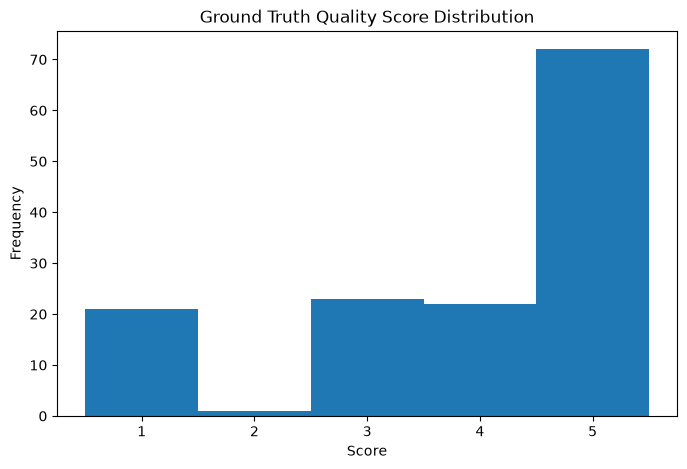

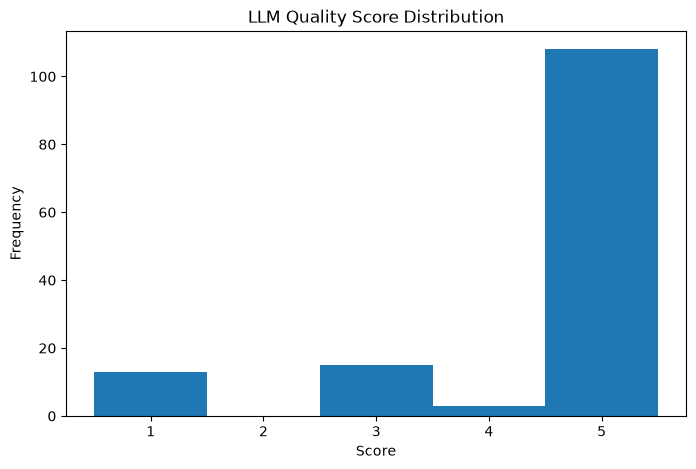

In [20]:

# Histogram distribution required by Section 7.3

plt.figure(figsize=(8,5))
plt.hist(df['gt_score'], bins=np.arange(1,7)-0.5)
plt.title('Ground Truth Quality Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['llm_score'], bins=np.arange(1,7)-0.5)
plt.title('LLM Quality Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()


In [21]:

# Descriptive statistics used to verify statistical assumptions

display(df['gt_score'].describe())
display(df['llm_score'].describe())

print('Interpretation:')
print('- If distribution approximately follows expected assumptions, keep test from proposal.')
print('- Otherwise document deviation in notes.md, project log, and amendment if required.')


count    139.000000
mean       3.884892
std        1.440004
min        1.000000
25%        3.000000
50%        5.000000
75%        5.000000
max        5.000000
Name: gt_score, dtype: float64

count    139.000000
mean       4.388489
std        1.259807
min        1.000000
25%        5.000000
50%        5.000000
75%        5.000000
max        5.000000
Name: llm_score, dtype: float64

Interpretation:
- If distribution approximately follows expected assumptions, keep test from proposal.
- Otherwise document deviation in notes.md, project log, and amendment if required.


In [22]:

# Cohen's Kappa (direct calculation)

from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(df['gt_score'], df['llm_score'])
print("Cohen Kappa =", round(kappa,4))


Cohen Kappa = 0.3345


In [23]:

# Run official script

import subprocess, os

script='Scripts/kappa_pilot.py'

if os.path.exists(script):
    subprocess.run(['python', script])
else:
    print('Copy kappa_pilot.py into Scripts/ and run this cell.')


Copy kappa_pilot.py into Scripts/ and run this cell.
